# Parametric Generator Evaluation
This notebook includes all the code used for the evaluation of the (univariate) parametric generator.
Specifically, it includes:
- Model and Component Loading
- Image Attribute Metrics Calculation and Plotting
- Image Preservation Metrics Calculation and Plotting
- Performance Benchmarking and Plotting

## Imports

In [1]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from social_media_overlay.ext.gebhardt.dataset.CocoCaptions import CocoCaptions
from social_media_overlay.models.regressor import EmotionRegressor
from social_media_overlay.models.parametric import (
    ConditionalParametricResidualMobileNetGenerator,
)
import time
from typing import Any, Dict, Optional, Tuple

from torch import Tensor
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from tqdm.auto import tqdm

from social_media_overlay.low_level_image_metrics import val_image_properties
from social_media_overlay.utils import to_tensor
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from typing import Any, Dict, List, Tuple
import seaborn as sns
from matplotlib.lines import Line2D
import math
from torch.utils.data import Subset


pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

sns.set_theme(style="white")

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

FIG_SIZE = (7, 2.5)


/home/marcel.schubert/data/BA_social_media_overlay/python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Device

In [2]:
%config InlineBackend.figure_format = 'svg'
device = torch.device('cuda')

# This block loads required dependencies
# We then load the cuda environment

print("Device Info")
print("Selected device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
    print("Current GPU index:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    print("GPU capability:", torch.cuda.get_device_capability())
else:
    print("Running on CPU")

Device Info
Selected device: cuda
CUDA available: True
CUDA version: 12.6
GPU count: 8
Current GPU index: 0
GPU name: Tesla P100-SXM2-16GB
GPU capability: (6, 0)


## Model Configuration

In [ ]:
# see main training code for more information!

COCO_DATA_PATH = "../data/coco"
EVAL_SPLIT = "test"

IMAGE_RESIZE_SIZE = 480
IMAGE_CROP_SIZE = 480

BATCH_SIZE = 8
NUM_WORKERS = 8
PIN_MEMORY = True
DROP_LAST_BATCH = False

# checkpoint
RESUME_CHECKPOINT_PATH = "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1-final.pt"

# regressor
REGRESSOR_MODEL_PATH = "../data/gebhardt/models/va_pred_all"
REGRESSOR_USE_AVERAGE = False
REGRESSOR_NORMALIZE_INPUT = True
REGRESSOR_USE_AROUSAL = True
FREEZE_REGRESSOR = True

# generator
GENERATOR_FC_DIM = 64
GENERATOR_FC_DEPTH = 3
GENERATOR_USE_PRETRAINED_BACKBONE = True
GENERATOR_FREEZE_BACKBONE = True

COLOR_HEAD_DEPTH = 2
COLOR_HEAD_DIM = 64
TONE_HEAD_DEPTH = 2
TONE_HEAD_DIM = 64

USE_FILM_CONDITIONING = True
USE_RES_HEAD = False
USE_ALPHA_HEAD = False
USE_SIDMOID_HEAD = True

ZERO_ALPHA_PROB = 0.1
IDENTITY_LOSS_WEIGHT = 0.0

## Load Components
IMPORTANT!
The ´subset_size´ defines the amount of samples that will be drawn for the evaluation computation!

In [ ]:
subset_size = 5000 

data_transforms = transforms.Compose(
    [
        transforms.Resize(IMAGE_RESIZE_SIZE),
        transforms.CenterCrop(IMAGE_CROP_SIZE),
        transforms.ToTensor(),
    ]
)

dataset = CocoCaptions(COCO_DATA_PATH, EVAL_SPLIT, data_transforms)

g = torch.Generator()
g.manual_seed(42)

dataset_size = len(dataset)


# deterministic random indices
indices = torch.randperm(dataset_size, generator=g)[:subset_size]

subset_dataset = Subset(dataset, indices)

eval_dataloader = DataLoader(
        subset_dataset,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=DROP_LAST_BATCH,
        persistent_workers=(NUM_WORKERS > 0),
    )
regressor = EmotionRegressor(
    path_to_model=REGRESSOR_MODEL_PATH,
    average=REGRESSOR_USE_AVERAGE,
    device=device,
    normalize=REGRESSOR_NORMALIZE_INPUT,
).to(device)
if FREEZE_REGRESSOR:
    for param in regressor.model.parameters():
        param.requires_grad = False

regressor.eval()

## Load Model

In [5]:
model = ConditionalParametricResidualMobileNetGenerator(
    fc_dim=GENERATOR_FC_DIM,
    fc_depth=GENERATOR_FC_DEPTH,
    mobilenet_pretrained=GENERATOR_USE_PRETRAINED_BACKBONE,
    freeze_backbone=GENERATOR_FREEZE_BACKBONE,
    color_head_depth=COLOR_HEAD_DEPTH,
    color_head_dim=COLOR_HEAD_DIM,
    tone_head_depth=TONE_HEAD_DEPTH,
    tone_head_dim=TONE_HEAD_DIM,
    use_film=USE_FILM_CONDITIONING,
    use_res_head=USE_RES_HEAD,
    use_alpha_head=USE_ALPHA_HEAD,
    use_sigmoid_head=USE_SIDMOID_HEAD,
).to(device)
checkpoint = torch.load(RESUME_CHECKPOINT_PATH)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

## Validation Run
You must adapt the train script to only run validation by setting the flag in the config.

In [ ]:
#!torchrun --standalone --nproc_per_node=8 ../src/social_media_overlay/ddp_train_parametric_main.py

## Image Attributes
This code may compute the image attribute metrics of the test set.
You may save this into a pandas supported format to avoid recomputation!
After computation plotting is shown.

In [ ]:
 # Target Dir to save the figures and the computed results
TARGET_DIR = "../data/models/chkp_param_raw_ref_arous_il0_clip5e-2_FILM_uni_480_b64_fc64-3_headfc64-2-sig_lr1e-4_1-1/"

### Code for the Computation
This is just the definition of the evaluation run.
You may execute it as is.
It loads samples from the test set and compute all image attribute metrics as well as image preservation scores.

In [7]:
MetricStats = Dict[str, Tensor]
RunningStats = Dict[str, Any]


def eval_image_attr_and_distribution(
    dataloader,
    model,
    regressor,
    device: torch.device,
    alpha: float,
    only_original: bool = False,
    show_progress: bool = False,
    status_update_freq: int = 10,
) -> Dict[str, Any]:
    """
    Evaluate image attribute statistics and distribution metrics for a model over a dataloader.

    In addition to image-property metrics, this also computes:
    - raw predicted valence/arousal statistics for original images
    - raw predicted valence/arousal statistics for transformed images
    - difference-based metrics (MSE / MAE) between transformed and original predictions
    - image L1 distance
    - FID / KID
    """
    if not isinstance(alpha, (int, float)):
        raise TypeError(f"alpha must be numeric, got {type(alpha)!r}")
    if status_update_freq <= 0:
        raise ValueError(f"status_update_freq must be > 0, got {status_update_freq}")

    model.eval()

    image_metric_names = (
        "colorfulness",
        "mean_brightness",
        "mean_saturation",
        "rms_contrast",
        "lighting_diversity",
        "blur_effect",
    )

    emotion_metric_names = (
        "valence",
        "arousal",
    )

    distance_metric_names = (
        "valence_mse",
        "valence_mae",
        "arousal_mse",
        "arousal_mae",
        "image_l1",
    )

    image_prefixes = ("original",) if only_original else ("original", "transformed")
    emotion_prefixes = ("original",) if only_original else ("original", "transformed")
    enabled_distance_metrics = () if only_original else distance_metric_names

    running_stats = make_running_stats(
        image_prefixes=image_prefixes,
        image_metric_names=image_metric_names,
        emotion_prefixes=emotion_prefixes,
        emotion_metric_names=emotion_metric_names,
        distance_metric_names=enabled_distance_metrics,
        device=device,
    )

    fid_metric = None
    kid_metric = None
    if not only_original:
        fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
        kid_metric = KernelInceptionDistance(
            feature=2048,
            subset_size=50,
            normalize=False,
        ).to(device)

    total_samples = get_total_samples(dataloader)
    progress_bar = None
    if show_progress:
        desc = f"Validation alpha={alpha:.3f}"
        if only_original:
            desc += " original-only"
        progress_bar = tqdm(
            total=total_samples,
            desc=desc,
            dynamic_ncols=True,
            leave=True,
        )

    seen_since_report = 0
    total_seen = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            images = get_images_from_batch(batch).to(device, non_blocking=True)
            batch_size = int(images.size(0))
            seen_since_report += batch_size

            original_metrics = val_image_properties(images)
            for name in image_metric_names:
                update_stats(running_stats["original"]["image"][name], original_metrics[name])

            # We can always compute regressor predictions for original images
            original_preds_raw = regressor.predict(images)
            original_preds = to_tensor(original_preds_raw, device, images.dtype)

            if original_preds.ndim == 1:
                original_preds = original_preds.unsqueeze(1)

            if original_preds.size(1) < 2:
                raise ValueError(
                    "Regressor predictions must contain at least 2 channels: "
                    "[valence, arousal]."
                )

            original_valence = original_preds[:, 0]
            original_arousal = original_preds[:, 1]

            update_stats(running_stats["original"]["emotion"]["valence"], original_valence)
            update_stats(running_stats["original"]["emotion"]["arousal"], original_arousal)

            if not only_original:
                alphas = torch.full(
                    (images.size(0),),
                    fill_value=float(alpha),
                    device=images.device,
                    dtype=torch.float32,
                )

                model_output = model(images, alphas)
                transformed_images = model_output[0] if isinstance(model_output, tuple) else model_output

                if not isinstance(transformed_images, Tensor):
                    raise TypeError(
                        "Model output must be a Tensor or a tuple whose first element is a Tensor."
                    )

                transformed_preds_raw = regressor.predict(transformed_images)
                transformed_preds = to_tensor(transformed_preds_raw, device, images.dtype)

                if transformed_preds.ndim == 1:
                    transformed_preds = transformed_preds.unsqueeze(1)

                if transformed_preds.size(1) < 2:
                    raise ValueError(
                        "Regressor predictions must contain at least 2 channels: "
                        "[valence, arousal]."
                    )

                transformed_metrics = val_image_properties(transformed_images)
                for name in image_metric_names:
                    update_stats(running_stats["transformed"]["image"][name], transformed_metrics[name])

                transformed_valence = transformed_preds[:, 0]
                transformed_arousal = transformed_preds[:, 1]

                update_stats(running_stats["transformed"]["emotion"]["valence"], transformed_valence)
                update_stats(running_stats["transformed"]["emotion"]["arousal"], transformed_arousal)

                valence_diff = transformed_valence - original_valence
                arousal_diff = transformed_arousal - original_arousal

                valence_mse = valence_diff ** 2
                valence_mae = valence_diff.abs()
                arousal_mse = arousal_diff ** 2
                arousal_mae = arousal_diff.abs()
                image_l1 = (transformed_images - images).abs().flatten(1).mean(dim=1)

                update_stats(running_stats["valence_mse"], valence_mse)
                update_stats(running_stats["valence_mae"], valence_mae)
                update_stats(running_stats["arousal_mse"], arousal_mse)
                update_stats(running_stats["arousal_mae"], arousal_mae)
                update_stats(running_stats["image_l1"], image_l1)

                original_uint8 = to_uint8_for_inception(images)
                transformed_uint8 = to_uint8_for_inception(transformed_images)

                fid_metric.update(original_uint8, real=True)
                fid_metric.update(transformed_uint8, real=False)
                kid_metric.update(original_uint8, real=True)
                kid_metric.update(transformed_uint8, real=False)

            should_report = ((batch_idx + 1) % status_update_freq == 0)
            if not should_report:
                try:
                    should_report = (batch_idx + 1) == len(dataloader)
                except TypeError:
                    should_report = False

            if should_report:
                total_seen += seen_since_report
                if progress_bar is not None:
                    if progress_bar.total is not None:
                        new_n = min(total_seen, progress_bar.total)
                        progress_bar.update(new_n - progress_bar.n)
                    else:
                        progress_bar.update(seen_since_report)
                seen_since_report = 0

    if progress_bar is not None:
        if seen_since_report > 0:
            total_seen += seen_since_report
            if progress_bar.total is not None:
                new_n = min(total_seen, progress_bar.total)
                progress_bar.update(new_n - progress_bar.n)
            else:
                progress_bar.update(seen_since_report)
        progress_bar.close()

    result: Dict[str, Any] = {}
    num_samples: Optional[int] = None

    for prefix in image_prefixes:
        for name in image_metric_names:
            mean, std, count = finalize_stats(running_stats[prefix]["image"][name])
            result[f"{prefix}_{name}_mean"] = mean
            result[f"{prefix}_{name}_std"] = std
            if num_samples is None:
                num_samples = count

    for prefix in emotion_prefixes:
        for name in emotion_metric_names:
            mean, std, count = finalize_stats(running_stats[prefix]["emotion"][name])
            result[f"{prefix}_{name}_mean"] = mean
            result[f"{prefix}_{name}_std"] = std
            if num_samples is None:
                num_samples = count

    for name in enabled_distance_metrics:
        mean, std, count = finalize_stats(running_stats[name])
        result[f"{name}_mean"] = mean
        result[f"{name}_std"] = std
        if num_samples is None:
            num_samples = count

    if not only_original:
        if fid_metric is None or kid_metric is None:
            raise RuntimeError("Distribution metrics were expected but not initialized.")

        fid_value = fid_metric.compute()
        kid_mean, kid_std = kid_metric.compute()

        result["fid"] = float(fid_value.item() if torch.is_tensor(fid_value) else fid_value)
        result["kid_mean"] = float(kid_mean.item() if torch.is_tensor(kid_mean) else kid_mean)
        result["kid_std"] = float(kid_std.item() if torch.is_tensor(kid_std) else kid_std)

    result["num_samples"] = 0 if num_samples is None else num_samples
    result["alpha"] = float(alpha)
    result["only_original"] = bool(only_original)

    return result


def get_images_from_batch(batch: Any) -> Tensor:
    if isinstance(batch, Tensor):
        return batch

    if isinstance(batch, (tuple, list)) and len(batch) > 0 and isinstance(batch[0], Tensor):
        return batch[0]

    raise TypeError(
        "Expected each batch to be a Tensor or a tuple/list whose first element is a Tensor."
    )


def get_total_samples(dataloader) -> Optional[int]:
    dataset = getattr(dataloader, "dataset", None)
    if dataset is None:
        return None

    try:
        return int(len(dataset))
    except TypeError:
        return None


def empty_stats(device: torch.device) -> MetricStats:
    return {
        "count": torch.tensor([0.0], device=device, dtype=torch.float64),
        "sum": torch.tensor([0.0], device=device, dtype=torch.float64),
        "sum_sq": torch.tensor([0.0], device=device, dtype=torch.float64),
    }


def make_running_stats(
    image_prefixes: Tuple[str, ...],
    image_metric_names: Tuple[str, ...],
    emotion_prefixes: Tuple[str, ...],
    emotion_metric_names: Tuple[str, ...],
    distance_metric_names: Tuple[str, ...],
    device: torch.device,
) -> RunningStats:
    stats: RunningStats = {}

    for prefix in image_prefixes:
        stats[prefix] = {
            "image": {name: empty_stats(device) for name in image_metric_names},
            "emotion": {name: empty_stats(device) for name in emotion_metric_names},
        }

    for name in distance_metric_names:
        stats[name] = empty_stats(device)

    return stats


def update_stats(stats: MetricStats, values: Tensor) -> None:
    values = values.detach().reshape(-1).to(torch.float64)
    stats["count"] += torch.tensor([values.numel()], device=values.device, dtype=torch.float64)
    stats["sum"] += values.sum().unsqueeze(0)
    stats["sum_sq"] += (values ** 2).sum().unsqueeze(0)


def finalize_stats(stats: MetricStats) -> Tuple[float, float, int]:
    count = float(stats["count"].item())
    if count <= 0:
        return 0.0, 0.0, 0

    mean = stats["sum"].item() / count
    variance = stats["sum_sq"].item() / count - mean * mean
    variance = max(variance, 0.0)
    std = variance ** 0.5

    return float(mean), float(std), int(count)


def to_uint8_for_inception(images: Tensor) -> Tensor:
    return (images.detach().clamp(0.0, 1.0) * 255.0).round().to(torch.uint8)

def evaluate_alpha_range(
    dataloader,
    model,
    regressor,
    device,
    alpha_min: float = -0.5,
    alpha_max: float = 0.5,
    num_steps: int = 5,
    only_original: bool = False,
    show_progress: bool = True,
):
    """
    Evaluate val_image_attr_and_distribution over an evenly spaced alpha range.

    Returns
    -------
    results_list : list[dict]
        One result dict per alpha.
    results_df : pandas.DataFrame
        Tabular version of the same results.
    """
    if num_steps < 2:
        raise ValueError("num_steps must be at least 2.")

    alphas = np.linspace(alpha_min, alpha_max, num_steps)

    results_list = []

    for alpha in alphas:
        result = eval_image_attr_and_distribution(
            dataloader=dataloader,
            model=model,
            regressor=regressor,
            device=device,
            alpha=float(alpha),
            only_original=only_original,
            show_progress=show_progress,
        )
        results_list.append(result)

    results_df = pd.DataFrame(results_list)
    return results_list, results_df

### Execute Computation
You may either execute the computation or load it using the code shown in the next cells.
This may take a long time to compute.

In [13]:
# Calculate image attribute metrics
results_list, results_df = evaluate_alpha_range(
    dataloader=eval_dataloader,
    model=model,
    regressor=regressor,
    device=device,
    alpha_min=-0.5,
    alpha_max=0.5,
    num_steps=17, # number of alphas (equal spacing)
    only_original=False, # unused for now
    show_progress=True, # progress bar
)

Validation alpha=0.500: 100%|██████████| 1000/1000 [00:28<00:00, 35.50it/s]


In [ ]:
# This is the file path of the saved metrics!
file_path = os.path.join(TARGET_DIR, "image_attribute_metrics_df.csv")

In [ ]:
# save image attribute metrics to csv
# or load it using code from cells below
results_df.to_csv(file_path, index=False)

### Image Attribute Plotting

In [ ]:
# Load the data from the path defined above
if os.path.exists(file_path):
    results_df = pd.read_csv(file_path)
else:
    results_df = None
    print("File not found.")

In [14]:
def get_available_metrics(results_df, transformed_prefix="transformed_", mean_suffix="_mean"):
    """
    Extract available metric names from columns like:
    transformed_accuracy_mean -> accuracy
    """
    metrics = []

    for col in results_df.columns:
        if col.startswith(transformed_prefix) and col.endswith(mean_suffix):
            metric = col.replace(transformed_prefix, "").replace(mean_suffix, "")
            metrics.append(metric)

    return sorted(metrics)

def plot_metric_grid(
    results_df,
    metrics=None,
    alpha_col="alpha",
    transformed_prefix="transformed_",
    mean_suffix="_mean",
    std_suffix="_std",
    ncols=3,
    figsize=(18, 10),
    cmap_name="tab10",
    linewidth=2.0,
    marker="o",
    markersize=4,
    band_alpha=0.18,
    sharex=True,
    sharey=False,
    show_grid=True,
    xlabel="Alpha",
    title="Metric Evolution over Alpha",
    save_dir="plots",
    filename="metric_grid.svg",
    dpi=300,
    bbox_inches="tight",
    show=False,
    show_legend=True,
    
    title_fontsize=16,
    subplot_title_fontsize=12,
    label_fontsize=11,
    tick_fontsize=10,
    legend_fontsize=11,
):
    os.makedirs(save_dir, exist_ok=True)

    df = results_df.copy()

    if alpha_col not in df.columns:
        raise ValueError(f"Missing required column: '{alpha_col}'")

    df = df.sort_values(alpha_col).reset_index(drop=True)

    if metrics is None:
        metrics = get_available_metrics(
            df,
            transformed_prefix=transformed_prefix,
            mean_suffix=mean_suffix
        )

    if not metrics:
        raise ValueError("No metrics found to plot.")

    # validate required columns
    missing_cols = []
    for metric in metrics:
        mean_col = f"{transformed_prefix}{metric}{mean_suffix}"
        std_col = f"{transformed_prefix}{metric}{std_suffix}"

        if mean_col not in df.columns:
            missing_cols.append(mean_col)
        if std_col not in df.columns:
            missing_cols.append(std_col)

    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")

    n_metrics = len(metrics)
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey
    )

    # make axes always iterable
    if nrows == 1 and ncols == 1:
        axes = np.array([axes])
    axes = np.array(axes).reshape(-1)

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(n_metrics)]

    x = df[alpha_col].to_numpy()

    legend_handles = []
    line_style_handle = None

    for i, metric in enumerate(metrics):
        ax = axes[i]
        color = colors[i]

        mean_col = f"{transformed_prefix}{metric}{mean_suffix}"
        std_col = f"{transformed_prefix}{metric}{std_suffix}"
        original_mean_col = f"original_{metric}{mean_suffix}"

        y = df[mean_col].to_numpy()
        y_std = df[std_col].to_numpy()

        ax.plot(
            x,
            y,
            color=color,
            marker=marker,
            markersize=markersize,
            linewidth=linewidth,
        )

        ax.fill_between(
            x,
            y - y_std,
            y + y_std,
            color=color,
            alpha=band_alpha,
        )

        if original_mean_col in df.columns:
            original_mean = df[original_mean_col].mean()

            ax.axhline(
                original_mean,
                color=color,
                linestyle="--",
                linewidth=linewidth * 0.9,
                alpha=0.9,
            )

            if line_style_handle is None:
                line_style_handle = Line2D(
                    [0], [0],
                    color="black",
                    linestyle="--",
                    linewidth=linewidth,
                    label="Original Mean"
                )

        ax.set_title(metric.replace("_", " ").title(), fontsize=subplot_title_fontsize)
        ax.set_xlabel(xlabel, fontsize=label_fontsize)
        ax.set_ylabel("Value", fontsize=label_fontsize)
        ax.tick_params(axis="both", labelsize=tick_fontsize)

        if show_grid:
            ax.grid(True, axis="y", alpha=0.5)
            #ax.minorticks_on()
            #ax.grid(True, which="minor", axis="y", linestyle=":", alpha=0.4)

        legend_handles.append(
            Line2D([0], [0], color=color, lw=linewidth, label=metric.replace("_", " ").title())
        )

    # hide empty axes
    for j in range(n_metrics, len(axes)):
        axes[j].axis("off")

    #fig.suptitle(title, fontsize=title_fontsize, fontweight="bold")

    if show_legend:
        fig.legend(
            handles=legend_handles + ([line_style_handle] if line_style_handle else []),
            loc="center right",
            bbox_to_anchor=(0.00, 0.5),
            frameon=False,
            ncol=1,
            fontsize=legend_fontsize
        )

    plt.tight_layout()
    
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=dpi, bbox_inches=bbox_inches)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return save_path

def plot_single_metric(
    results_df,
    metric,
    metric_type=None,
    alpha_col="alpha",
    mean_suffix="_mean",
    std_suffix="_std",
    figsize=(10, 6),
    linewidth=2.0,
    marker="o",
    markersize=5,
    band_alpha=0.2,
    xlabel="Alpha",
    ylabel=None,
    title=None,
    show_grid=True,
    show=False,
    save_dir="plots",
    filename=None,
    dpi=300,
    bbox_inches="tight",
    annotate=False,
    annotation_fontsize=9,
    reference_metric=None,
    reference_label=None,
    reference_linestyle="--",
    reference_linewidth=2.0,
):
    df = results_df.copy()

    if alpha_col not in df.columns:
        raise ValueError(f"Missing required column: '{alpha_col}'")

    df = df.sort_values(alpha_col).reset_index(drop=True)

    def resolve_cols(metric_name, metric_type=None):
        if metric_type is not None:
            mean_candidates = [
                f"{metric_name}_{metric_type}{mean_suffix}",
                f"{metric_name}_{metric_type}",
            ]
            std_candidates = [
                f"{metric_name}_{metric_type}{std_suffix}",
            ]
        else:
            mean_candidates = [
                f"{metric_name}{mean_suffix}",
                metric_name,
            ]
            std_candidates = [
                f"{metric_name}{std_suffix}",
            ]

        mean_col = next((col for col in mean_candidates if col in df.columns), None)
        std_col = next((col for col in std_candidates if col in df.columns), None)
        return mean_col, std_col, mean_candidates

    mean_col, std_col, mean_candidates = resolve_cols(metric, metric_type)

    if mean_col is None:
        raise ValueError(
            f"Could not find a value column for metric='{metric}' "
            f"and metric_type='{metric_type}'. Tried: {mean_candidates}"
        )

    required = [alpha_col, mean_col]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    x = df[alpha_col]
    y = df[mean_col]
    y_std = df[std_col] if std_col is not None else None

    metric_label = (
        metric.replace("_", " ").upper()
        if metric.lower() in {"fid", "kid"}
        else metric.replace("_", " ").title()
    )

    if ylabel is None:
        ylabel = metric_type.upper() if metric_type is not None else metric_label

    if title is None:
        if metric_type is not None:
            title = f"{metric_label} ({metric_type.upper()}) over Alpha"
        else:
            title = f"{metric_label} over Alpha"

    plt.figure(figsize=figsize)

    # main curve
    plt.plot(
        x,
        y,
        marker=marker,
        markersize=markersize,
        linewidth=linewidth,
        label=metric_label,
    )

    if y_std is not None:
        plt.fill_between(
            x,
            y - y_std,
            y + y_std,
            alpha=band_alpha,
            label=f"{metric_label} ± std",
        )

    # optional reference baseline
    if reference_metric is not None:
        ref_mean_col, ref_std_col, ref_candidates = resolve_cols(reference_metric, None)

        if ref_mean_col is None:
            raise ValueError(
                f"Could not find reference mean column for reference_metric='{reference_metric}'. "
                f"Tried: {ref_candidates}"
            )

        ref_mean = df[ref_mean_col].iloc[0]
        ref_std = df[ref_std_col].iloc[0] if ref_std_col is not None else None

        if reference_label is None:
            reference_label = reference_metric.replace("_", " ").title()

        plt.axhline(
            y=ref_mean,
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            label=reference_label,
        )

        if ref_std is not None:
            plt.fill_between(
                x,
                ref_mean - ref_std,
                ref_mean + ref_std,
                alpha=band_alpha,
                label=f"{reference_label} ± std",
            )

    if annotate:
        if y_std is not None:
            for xi, yi, si in zip(x, y, y_std):
                plt.text(
                    xi,
                    yi,
                    f"{yi:.5f}\n±{si:.5f}",
                    ha="center",
                    va="bottom",
                    fontsize=annotation_fontsize,
                )
        else:
            for xi, yi in zip(x, y):
                plt.text(
                    xi,
                    yi,
                    f"{yi:.5f}",
                    ha="center",
                    va="bottom",
                    fontsize=annotation_fontsize,
                )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    #plt.title(title)

    if show_grid:
        plt.grid(True, alpha=0.3)

    plt.legend()
    plt.tight_layout()

    save_path = None
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

        if filename is None:
            if metric_type is not None:
                filename = f"{metric}_{metric_type}.svg"
            else:
                filename = f"{metric}.svg"

        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi=dpi, bbox_inches=bbox_inches)

    if show:
        plt.show()
    else:
        plt.close()

    return save_path

In [11]:
results_df.columns

Index(['original_colorfulness_mean', 'original_colorfulness_std',
       'original_mean_brightness_mean', 'original_mean_brightness_std',
       'original_mean_saturation_mean', 'original_mean_saturation_std',
       'original_rms_contrast_mean', 'original_rms_contrast_std',
       'original_lighting_diversity_mean', 'original_lighting_diversity_std',
       'original_blur_effect_mean', 'original_blur_effect_std',
       'transformed_colorfulness_mean', 'transformed_colorfulness_std',
       'transformed_mean_brightness_mean', 'transformed_mean_brightness_std',
       'transformed_mean_saturation_mean', 'transformed_mean_saturation_std',
       'transformed_rms_contrast_mean', 'transformed_rms_contrast_std',
       'transformed_lighting_diversity_mean',
       'transformed_lighting_diversity_std', 'transformed_blur_effect_mean',
       'transformed_blur_effect_std', 'original_valence_mean',
       'original_valence_std', 'original_arousal_mean', 'original_arousal_std',
       'transfor

In [ ]:
# use params save_dir="plots", filename="metric_grid.svg",
# to control target location

save_path = plot_metric_grid(
    results_df=results_df,
    metrics=[
        "blur_effect",
        "colorfulness",
        "lighting_diversity",
        "mean_brightness",
        "mean_saturation",
        "rms_contrast"
    ],
    ncols=3,
    figsize=(15, 8),
    cmap_name="tab10",
    title="Evolution of Metrics over Alpha",
    filename="all_image_attribute_metrics_grid.svg",
    title_fontsize=25,
    subplot_title_fontsize=20,
    label_fontsize=18,
    tick_fontsize=15,
    legend_fontsize=10,
    
    show_legend=False,
)

### Single Plots
These plots are used for the affect score and KID,FID as well as L1 figures.

In [ ]:
# use params save_dir="plots", filename="metric_grid.svg",
# to control target location

# valence / arousal
plot_single_metric(results_df, metric="valence", metric_type="mse", filename="valence_mse.svg")
plot_single_metric(results_df, metric="arousal", metric_type="mse", filename="arousal_mse.svg")

plot_single_metric(results_df, metric="valence", metric_type="mae", filename="valence_mae.svg")
plot_single_metric(results_df, metric="arousal", metric_type="mae", filename="valence_mae.svg")

plot_single_metric(
    results_df,
    metric="transformed_valence",
    reference_metric="original_valence",
    reference_label="Original Valence",
    filename="valence.svg",
)

plot_single_metric(
    results_df,
    metric="transformed_arousal",
    reference_metric="original_arousal",
    reference_label="Original Arousal",
    filename="arousal.svg",
)

# kid
plot_single_metric(results_df, metric="kid", metric_type=None, filename="kid.svg")

# fid
plot_single_metric(results_df, metric="fid", metric_type=None, filename="fid.svg")

# fid
plot_single_metric(results_df, metric="image_l1", filename="image_l1.svg")

'plots/image_l1.svg'

### Image Preservation Metric Avg

In [11]:
fid_mean = results_df["fid"].mean()
kid_mean = results_df["kid_mean"].mean()
l1_mean = results_df["image_l1_mean"].mean()

print(f"Mean FID: {fid_mean:.5f}")
print(f"Mean KID: {kid_mean:.5f}")
print(f"Mean l1: {l1_mean:.5f}")

Mean FID: 67.31327
Mean KID: 0.02484
Mean l1: 0.18208


## Benchmarking
In the following section the benchmarking is conducted as described within the report.

In [ ]:
# Only definitions here
def benchmark_model_inference(
    dataloader,
    model,
    device: torch.device,
    alpha: float = -0.1,
    warmup_batches: int = 10,
    use_amp: bool = False,
    amp_dtype: Optional[torch.dtype] = None,
    max_batches: Optional[int] = None,
) -> Dict[str, Any]:
    """
    Benchmark model-only inference on a dataloader using a fixed alpha.

    Returns a flat result dict with throughput and latency statistics.
    """

    if not isinstance(alpha, (int, float)):
        raise TypeError(f"alpha must be numeric, got {type(alpha)!r}")
    if warmup_batches < 0:
        raise ValueError(f"warmup_batches must be >= 0, got {warmup_batches}")
    if max_batches is not None and max_batches <= 0:
        raise ValueError(f"max_batches must be > 0 if provided, got {max_batches}")

    model.eval()

    if amp_dtype is None and device.type == "cuda":
        amp_dtype = torch.float16

    batch_times_s = []
    per_image_times_s = []
    batch_sizes = []

    num_samples = 0
    num_batches = 0
    last_output_shape = None

    with torch.inference_mode():
        warmup_done = 0
        for batch in dataloader:
            images = get_images_from_batch(batch).to(device, non_blocking=True)
            alphas = make_alpha_tensor(images.size(0), alpha, device)

            synchronize_if_needed(device)
            if use_amp and device.type == "cuda":
                with torch.autocast(device_type="cuda", dtype=amp_dtype):
                    output = model(images, alphas)
            else:
                output = model(images, alphas)
            _ = unwrap_model_output(output)
            synchronize_if_needed(device)

            warmup_done += 1
            if warmup_done >= warmup_batches:
                break

    synchronize_if_needed(device)
    total_start = time.perf_counter()

    with torch.inference_mode():
        for batch in dataloader:
            if max_batches is not None and num_batches >= max_batches:
                break

            images = get_images_from_batch(batch)
            batch_size = int(images.size(0))

            images = images.to(device, non_blocking=True)
            alphas = make_alpha_tensor(batch_size, alpha, device)

            synchronize_if_needed(device)
            start = time.perf_counter()

            if use_amp and device.type == "cuda":
                with torch.autocast(device_type="cuda", dtype=amp_dtype):
                    output = model(images, alphas)
            else:
                output = model(images, alphas)

            outputs = unwrap_model_output(output)

            synchronize_if_needed(device)
            end = time.perf_counter()

            batch_time = end - start

            batch_times_s.append(batch_time)
            per_image_times_s.append(batch_time / batch_size)
            batch_sizes.append(batch_size)

            num_samples += batch_size
            num_batches += 1
            last_output_shape = tuple(outputs.shape)

    synchronize_if_needed(device)
    total_end = time.perf_counter()

    total_time_s = total_end - total_start
    timed_forward_time_s = float(sum(batch_times_s))

    result = {
        "alpha": float(alpha),
        "device": str(device),
        "use_amp": bool(use_amp),
        "amp_dtype": str(amp_dtype) if amp_dtype is not None else None,
        "warmup_batches": int(warmup_batches),
        "num_batches": int(num_batches),
        "num_samples": int(num_samples),
        "total_wall_time_s": float(total_time_s),
        "timed_forward_time_s": float(timed_forward_time_s),
        "throughput_images_per_s": (
            float(num_samples / timed_forward_time_s) if timed_forward_time_s > 0 else 0.0
        ),
        "throughput_batches_per_s": (
            float(num_batches / timed_forward_time_s) if timed_forward_time_s > 0 else 0.0
        ),
        "batch_size_mean": safe_mean(batch_sizes),
        "batch_size_std": safe_std(batch_sizes),
        "batch_size_min": int(min(batch_sizes)) if batch_sizes else 0,
        "batch_size_max": int(max(batch_sizes)) if batch_sizes else 0,
        "latency_batch_mean_ms": 1000.0 * safe_mean(batch_times_s),
        "latency_batch_std_ms": 1000.0 * safe_std(batch_times_s),
        "latency_batch_min_ms": 1000.0 * (min(batch_times_s) if batch_times_s else 0.0),
        "latency_batch_max_ms": 1000.0 * (max(batch_times_s) if batch_times_s else 0.0),
        "latency_batch_p50_ms": 1000.0 * percentile(batch_times_s, 50),
        "latency_batch_p95_ms": 1000.0 * percentile(batch_times_s, 95),
        "latency_batch_p99_ms": 1000.0 * percentile(batch_times_s, 99),
        "latency_image_mean_ms": 1000.0 * safe_mean(per_image_times_s),
        "latency_image_std_ms": 1000.0 * safe_std(per_image_times_s),
        "latency_image_min_ms": 1000.0 * (min(per_image_times_s) if per_image_times_s else 0.0),
        "latency_image_max_ms": 1000.0 * (max(per_image_times_s) if per_image_times_s else 0.0),
        "latency_image_p50_ms": 1000.0 * percentile(per_image_times_s, 50),
        "latency_image_p95_ms": 1000.0 * percentile(per_image_times_s, 95),
        "latency_image_p99_ms": 1000.0 * percentile(per_image_times_s, 99),
        "last_output_shape": last_output_shape,
    }

    return result


def get_images_from_batch(batch: Any) -> Tensor:
    if isinstance(batch, Tensor):
        return batch

    if isinstance(batch, (tuple, list)) and len(batch) > 0:
        if isinstance(batch[0], Tensor):
            return batch[0]

    if isinstance(batch, dict):
        for key in ["image", "images", "img", "x", "input"]:
            if key in batch and isinstance(batch[key], Tensor):
                return batch[key]

    raise TypeError(
        "Expected batch to be a Tensor, a tuple/list whose first element is a Tensor, "
        "or a dict containing an image Tensor."
    )


def make_alpha_tensor(batch_size: int, alpha: float, device: torch.device) -> Tensor:
    return torch.full(
        (batch_size,),
        fill_value=float(alpha),
        device=device,
        dtype=torch.float32,
    )


def unwrap_model_output(output: Any) -> Tensor:
    if isinstance(output, Tensor):
        return output

    if isinstance(output, (tuple, list)) and len(output) > 0 and isinstance(output[0], Tensor):
        return output[0]

    raise TypeError(
        "Model output must be a Tensor or a tuple/list whose first element is a Tensor."
    )


def synchronize_if_needed(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def safe_mean(values) -> float:
    if len(values) == 0:
        return 0.0
    return float(np.mean(values))


def safe_std(values) -> float:
    if len(values) == 0:
        return 0.0
    return float(np.std(values, ddof=0))


def percentile(values, q: float) -> float:
    if len(values) == 0:
        return 0.0
    return float(np.percentile(np.asarray(values, dtype=np.float64), q))

### Model Wrapper without Transformations
Model wrapper code that only returns parameter predictions no adjusted images

In [ ]:
# just definitions
class ParamsOnlyWrapper(torch.nn.Module):
    """
    Wrapper for ConditionalParametricResidualMobileNetGenerator that keeps the
    original forward call, but returns only flat_params.

    The generated image output is discarded.
    """

    def __init__(self, generator: ConditionalParametricResidualMobileNetGenerator):
        super().__init__()
        self.generator = generator

    def forward(self, x, alpha):
        _, flat_params = self.generator(x, alpha)
        return flat_params

    def train(self, mode=True):
        self.generator.train(mode)
        return super().train(mode)
    
params_only_model = ParamsOnlyWrapper(model).to(device)
params_only_model.eval()

#### Start benchmarking

In [ ]:
result_perf_dict = benchmark_model_inference(
    dataloader=eval_dataloader,
    model=model,
    device=device,
    alpha=-0.1,
    warmup_batches=10,
    use_amp=False,
    max_batches=None,
)

#### Save Benchmarking Results to df

In [ ]:
results_perf_df = pd.DataFrame([result_perf_dict])

In [ ]:
# save performance metrics to csv
file_path_perf_df = os.path.join(TARGET_DIR, "model_inference_perf_metrics_df.csv")
results_perf_df.to_csv(file_path_perf_df, index=False)

#### Plot Performance
Load saved performance benchmark results and plot

In [ ]:
# Load
file_path_perf_df = os.path.join(TARGET_DIR, "model_inference_perf_metrics_df.csv")

if os.path.exists(file_path_perf_df):
    results_perf_df = pd.read_csv(file_path_perf_df)
else:
    results_perf_df = None
    print("File not found.")

In [11]:
results_perf_df

,alpha,device,use_amp,amp_dtype,warmup_batches,num_batches,num_samples,total_wall_time_s,timed_forward_time_s,throughput_images_per_s,throughput_batches_per_s,batch_size_mean,batch_size_std,batch_size_min,batch_size_max,latency_batch_mean_ms,latency_batch_std_ms,latency_batch_min_ms,latency_batch_max_ms,latency_batch_p50_ms,latency_batch_p95_ms,latency_batch_p99_ms,latency_image_mean_ms,latency_image_std_ms,latency_image_min_ms,latency_image_max_ms,latency_image_p50_ms,latency_image_p95_ms,latency_image_p99_ms,last_output_shape
0,-0.1,cuda,False,torch.float16,10,625,5000,20.402632,18.58891,268.977572,33.622196,8.0,0.0,8,8,29.742257,3.037164,24.360444,39.892856,29.678971,34.727979,37.152376,3.717782,0.379646,3.045056,4.986607,3.709871,4.340997,4.644047,"(8, 3, 480, 480)"


In [ ]:
# Plotting definitions
def plot_single_benchmark_summary(results_df):
    """
    Create a research-style summary figure for a single-row benchmark dataframe.
    """
    if len(results_df) != 1:
        raise ValueError(f"Expected exactly 1 row, got {len(results_df)}")

    row = results_df.iloc[0]

    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0], width_ratios=[1.05, 1.0])

    ax1 = fig.add_subplot(gs[0, 0])  # throughput
    ax2 = fig.add_subplot(gs[0, 1])  # batch latency
    ax3 = fig.add_subplot(gs[1, 0])  # image latency
    ax4 = fig.add_subplot(gs[1, 1])  # text summary

    # -------------------------
    # 1) Throughput panel
    # -------------------------
    throughput_names = ["Images/s", "Batches/s"]
    throughput_vals = [
        row["throughput_images_per_s"],
        row["throughput_batches_per_s"],
    ]

    bars = ax1.bar(throughput_names, throughput_vals)
    ax1.set_title("Inference Throughput", pad=12)
    ax1.set_ylabel("Rate")
    ax1.grid(True, axis="y", alpha=0.3)

    ymax = max(throughput_vals) * 1.2 if max(throughput_vals) > 0 else 1.0
    ax1.set_ylim(0, ymax)

    for bar, val in zip(bars, throughput_vals):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    # -------------------------
    # 2) Batch latency panel
    # -------------------------
    batch_latency_names = ["Mean", "P50", "P95", "P99"]
    batch_latency_vals = [
        row["latency_batch_mean_ms"],
        row["latency_batch_p50_ms"],
        row["latency_batch_p95_ms"],
        row["latency_batch_p99_ms"],
    ]

    bars = ax2.bar(batch_latency_names, batch_latency_vals)
    ax2.set_title("Batch Latency", pad=12)
    ax2.set_ylabel("Latency (ms)")
    ax2.grid(True, axis="y", alpha=0.3)

    ymax = max(batch_latency_vals) * 1.2 if max(batch_latency_vals) > 0 else 1.0
    ax2.set_ylim(0, ymax)

    for bar, val in zip(bars, batch_latency_vals):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    # -------------------------
    # 3) Image latency panel
    # -------------------------
    image_latency_names = ["Mean", "P50", "P95", "P99"]
    image_latency_vals = [
        row["latency_image_mean_ms"],
        row["latency_image_p50_ms"],
        row["latency_image_p95_ms"],
        row["latency_image_p99_ms"],
    ]

    bars = ax3.bar(image_latency_names, image_latency_vals)
    ax3.set_title("Per-Image Latency", pad=12)
    ax3.set_ylabel("Latency (ms)")
    ax3.grid(True, axis="y", alpha=0.3)

    ymax = max(image_latency_vals) * 1.25 if max(image_latency_vals) > 0 else 1.0
    ax3.set_ylim(0, ymax)

    for bar, val in zip(bars, image_latency_vals):
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    # -------------------------
    # 4) Summary text panel
    # -------------------------
    ax4.axis("off")

    summary_lines = [
        "Benchmark summary",
        "",
        f"Alpha: {row['alpha']}",
        f"Device: {row['device']}",
        f"AMP: {row['use_amp']}",
        f"AMP dtype: {row['amp_dtype']}",
        "",
        f"Samples: {int(row['num_samples'])}",
        f"Batches: {int(row['num_batches'])}",
        f"Warmup batches: {int(row['warmup_batches'])}",
        "",
        f"Total wall time: {row['total_wall_time_s']:.3f} s",
        f"Timed forward time: {row['timed_forward_time_s']:.3f} s",
        "",
        f"Batch size mean: {row['batch_size_mean']:.2f}",
        f"Batch size std: {row['batch_size_std']:.2f}",
        f"Batch size min/max: {int(row['batch_size_min'])} / {int(row['batch_size_max'])}",
        "",
        f"Output shape: {row['last_output_shape']}",
    ]

    ax4.text(
        0.02,
        0.98,
        "\n".join(summary_lines),
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
        bbox=dict(boxstyle="round,pad=0.6", alpha=0.08),
    )

    fig.suptitle("Inference Benchmark Overview", fontsize=16, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

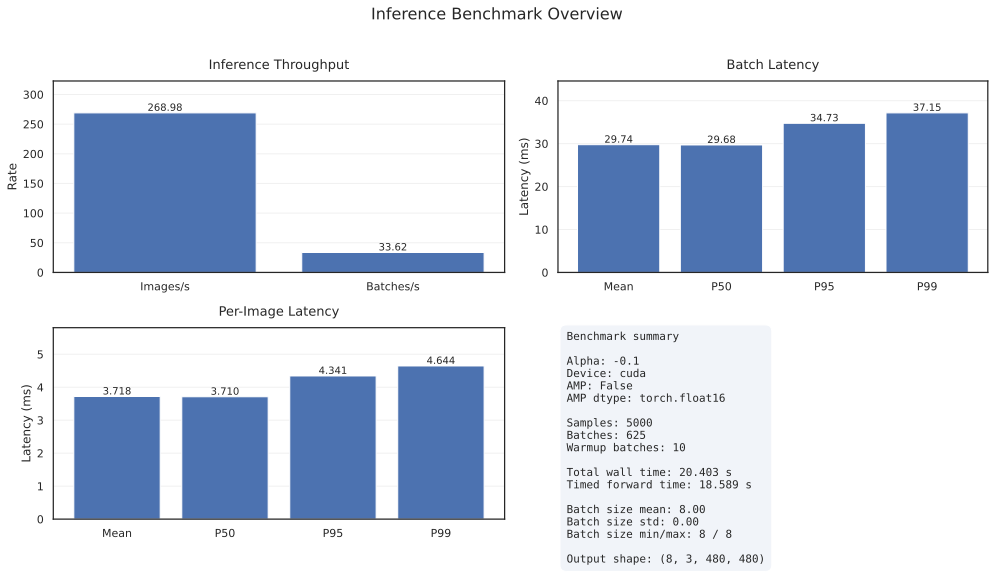

In [ ]:
# Plot
plot_single_benchmark_summary(results_perf_df)

# OLS
The following section conducts OLS regression as described within  the report

In [1]:
# OLS definitions
def collect_emotion_predictions_over_alpha(
    dataloader,
    model,
    regressor,
    device: torch.device,
    alpha_min: float = -0.5,
    alpha_max: float = 0.5,
    num_steps: int = 13,
    show_progress: bool = True,
) -> pd.DataFrame:
    """
    Collect per-image emotion predictions over a range of alpha values.

    Returns
    -------
    df : pd.DataFrame
        One row per image per alpha with columns:
        - image_id
        - alpha
        - original_valence
        - original_arousal
        - transformed_valence
        - transformed_arousal
        - delta_valence
        - delta_arousal
        - arousal_error_vs_alpha
        - abs_arousal_error_vs_alpha
        - sq_arousal_error_vs_alpha
    """
    if num_steps < 2:
        raise ValueError("num_steps must be at least 2.")

    model.eval()
    alphas = np.linspace(alpha_min, alpha_max, num_steps)

    rows: List[Dict[str, float]] = []

    total_batches = None
    try:
        total_batches = len(dataloader)
    except TypeError:
        pass

    total_progress = None
    if total_batches is not None:
        total_progress = total_batches * len(alphas)

    progress_bar = tqdm(
        total=total_progress,
        desc="Collecting alpha predictions",
        disable=not show_progress,
        dynamic_ncols=True,
    )

    with torch.no_grad():
        for alpha in alphas:
            image_counter = 0

            for batch in dataloader:
                images = get_images_from_batch(batch).to(device, non_blocking=True)
                batch_size = int(images.size(0))

                original_preds_raw = regressor.predict(images)
                original_preds = to_tensor(original_preds_raw, device, images.dtype)

                if original_preds.ndim == 1:
                    original_preds = original_preds.unsqueeze(1)

                if original_preds.size(1) < 2:
                    raise ValueError(
                        "Regressor predictions must contain at least 2 channels: "
                        "[valence, arousal]."
                    )

                alpha_tensor = torch.full(
                    (batch_size,),
                    fill_value=float(alpha),
                    device=images.device,
                    dtype=torch.float32,
                )

                model_output = model(images, alpha_tensor)
                transformed_images = model_output[0] if isinstance(model_output, tuple) else model_output

                if not isinstance(transformed_images, Tensor):
                    raise TypeError(
                        "Model output must be a Tensor or a tuple whose first element is a Tensor."
                    )

                transformed_preds_raw = regressor.predict(transformed_images)
                transformed_preds = to_tensor(transformed_preds_raw, device, images.dtype)

                if transformed_preds.ndim == 1:
                    transformed_preds = transformed_preds.unsqueeze(1)

                if transformed_preds.size(1) < 2:
                    raise ValueError(
                        "Regressor predictions must contain at least 2 channels: "
                        "[valence, arousal]."
                    )

                original_valence = original_preds[:, 0].detach().cpu().numpy()
                original_arousal = original_preds[:, 1].detach().cpu().numpy()
                transformed_valence = transformed_preds[:, 0].detach().cpu().numpy()
                transformed_arousal = transformed_preds[:, 1].detach().cpu().numpy()

                for i in range(batch_size):
                    delta_valence = float(transformed_valence[i] - original_valence[i])
                    delta_arousal = float(transformed_arousal[i] - original_arousal[i])
                    arousal_error = float(delta_arousal - alpha)

                    rows.append({
                        "image_id": int(image_counter + i),
                        "alpha": float(alpha),
                        "original_valence": float(original_valence[i]),
                        "original_arousal": float(original_arousal[i]),
                        "transformed_valence": float(transformed_valence[i]),
                        "transformed_arousal": float(transformed_arousal[i]),
                        "delta_valence": delta_valence,
                        "delta_arousal": delta_arousal,
                        "arousal_error_vs_alpha": arousal_error,
                        "abs_arousal_error_vs_alpha": abs(arousal_error),
                        "sq_arousal_error_vs_alpha": arousal_error ** 2,
                    })

                image_counter += batch_size
                progress_bar.update(1)

    progress_bar.close()

    df = pd.DataFrame(rows)
    return df

def make_alpha_level_summary(pred_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize mean/std behaviour at each alpha.
    """
    required_cols = {
        "alpha",
        "image_id",
        "original_arousal",
        "transformed_arousal",
        "delta_arousal",
        "original_valence",
        "transformed_valence",
        "delta_valence",
        "arousal_error_vs_alpha",
        "abs_arousal_error_vs_alpha",
        "sq_arousal_error_vs_alpha",
    }
    missing = required_cols - set(pred_df.columns)
    if missing:
        raise ValueError(f"pred_df is missing required columns: {sorted(missing)}")

    summary_df = (
        pred_df.groupby("alpha", as_index=False)
        .agg(
            mean_original_arousal=("original_arousal", "mean"),
            std_original_arousal=("original_arousal", "std"),
            mean_transformed_arousal=("transformed_arousal", "mean"),
            std_transformed_arousal=("transformed_arousal", "std"),
            mean_delta_arousal=("delta_arousal", "mean"),
            std_delta_arousal=("delta_arousal", "std"),
            mean_original_valence=("original_valence", "mean"),
            std_original_valence=("original_valence", "std"),
            mean_transformed_valence=("transformed_valence", "mean"),
            std_transformed_valence=("transformed_valence", "std"),
            mean_delta_valence=("delta_valence", "mean"),
            std_delta_valence=("delta_valence", "std"),
            arousal_error_bias=("arousal_error_vs_alpha", "mean"),
            arousal_error_mae=("abs_arousal_error_vs_alpha", "mean"),
            arousal_error_mse=("sq_arousal_error_vs_alpha", "mean"),
            n=("image_id", "count"),
        )
    )

    summary_df["arousal_error_rmse"] = np.sqrt(summary_df["arousal_error_mse"])
    return summary_df

def fit_alpha_control_models(pred_df: pd.DataFrame):
    """
    Fit OLS models with cluster-robust SE by image_id.

    Models:
    - delta_arousal ~ alpha
    - delta_valence ~ alpha
    """
    required_cols = {"image_id", "alpha", "delta_arousal", "delta_valence"}
    missing = required_cols - set(pred_df.columns)
    if missing:
        raise ValueError(f"pred_df is missing required columns: {sorted(missing)}")

    arousal_model = smf.ols(
        "delta_arousal ~ alpha",
        data=pred_df,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": pred_df["image_id"]},
    )

    valence_model = smf.ols(
        "delta_valence ~ alpha",
        data=pred_df,
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": pred_df["image_id"]},
    )

    return arousal_model, valence_model

def summarize_alpha_control_results(
    pred_df: pd.DataFrame,
    arousal_model,
    valence_model,
) -> pd.DataFrame:
    """
    Return one-row DataFrame with the most important controllability metrics.
    """
    summary = {
        "arousal_intercept": float(arousal_model.params.get("Intercept", np.nan)),
        "arousal_intercept_p": float(arousal_model.pvalues.get("Intercept", np.nan)),
        "arousal_alpha_slope": float(arousal_model.params.get("alpha", np.nan)),
        "arousal_alpha_slope_p": float(arousal_model.pvalues.get("alpha", np.nan)),
        "arousal_r_squared": float(arousal_model.rsquared),
        "arousal_slope_error_from_1": float(abs(arousal_model.params.get("alpha", np.nan) - 1.0)),
        "arousal_intercept_error_from_0": float(abs(arousal_model.params.get("Intercept", np.nan))),
        "arousal_error_mae": float(pred_df["abs_arousal_error_vs_alpha"].mean()),
        "arousal_error_mse": float(pred_df["sq_arousal_error_vs_alpha"].mean()),
        "arousal_error_rmse": float(np.sqrt(pred_df["sq_arousal_error_vs_alpha"].mean())),
        "arousal_error_bias": float(pred_df["arousal_error_vs_alpha"].mean()),
        "valence_intercept": float(valence_model.params.get("Intercept", np.nan)),
        "valence_intercept_p": float(valence_model.pvalues.get("Intercept", np.nan)),
        "valence_alpha_slope": float(valence_model.params.get("alpha", np.nan)),
        "valence_alpha_slope_p": float(valence_model.pvalues.get("alpha", np.nan)),
        "valence_r_squared": float(valence_model.rsquared),
        "num_rows": int(len(pred_df)),
        "num_images": int(pred_df["image_id"].nunique()),
        "num_alphas": int(pred_df["alpha"].nunique()),
    }

    return pd.DataFrame([summary])

def ols_result_to_df(model, model_name: str) -> pd.DataFrame:
    rows = []

    for term in model.params.index:
        rows.append({
            "model": model_name,
            "term": term,
            "coef": float(model.params[term]),
            "std_err": float(model.bse[term]),
            "t_value": float(model.tvalues[term]),
            "p_value": float(model.pvalues[term]),
            "ci_low": float(model.conf_int().loc[term, 0]),
            "ci_high": float(model.conf_int().loc[term, 1]),
            "r_squared": float(model.rsquared),
            "nobs": int(model.nobs),
        })

    return pd.DataFrame(rows)


def plot_mean_delta_arousal_vs_alpha(
    alpha_summary_df: pd.DataFrame,
    show_ideal: bool = True,
    figsize: Tuple[float, float] = (7, 5),
) -> None:
    plt.figure(figsize=figsize)
    plt.plot(
        alpha_summary_df["alpha"],
        alpha_summary_df["mean_delta_arousal"],
        marker="o",
        label="Observed mean Δ arousal",
    )

    if show_ideal:
        plt.plot(
            alpha_summary_df["alpha"],
            alpha_summary_df["alpha"],
            linestyle="--",
            label="Ideal Δ arousal = alpha",
        )

    plt.xlabel("alpha")
    plt.ylabel("Δ arousal")
    plt.title("Arousal control across alpha")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
def plot_mean_delta_valence_vs_alpha(
    alpha_summary_df: pd.DataFrame,
    figsize: Tuple[float, float] = (7, 5),
) -> None:
    plt.figure(figsize=figsize)
    plt.plot(
        alpha_summary_df["alpha"],
        alpha_summary_df["mean_delta_valence"],
        marker="o",
    )
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("alpha")
    plt.ylabel("Δ valence")
    plt.title("Indirect valence change across alpha")
    plt.tight_layout()
    plt.show()
    
def print_alpha_control_report(summary_df: pd.DataFrame) -> None:
    if len(summary_df) != 1:
        raise ValueError("summary_df must contain exactly one row.")

    row = summary_df.iloc[0]

    print("\n=== AROUSAL CONTROL MODEL: delta_arousal ~ alpha ===")
    print(f"Intercept (ideal 0): {row['arousal_intercept']:.6f} "
          f"(p={row['arousal_intercept_p']:.6g})")
    print(f"Slope for alpha (ideal 1): {row['arousal_alpha_slope']:.6f} "
          f"(p={row['arousal_alpha_slope_p']:.6g})")
    print(f"R^2: {row['arousal_r_squared']:.6f}")
    print(f"|slope - 1|: {row['arousal_slope_error_from_1']:.6f}")
    print(f"|intercept - 0|: {row['arousal_intercept_error_from_0']:.6f}")

    print("\n=== DIRECT ALIGNMENT TO delta_arousal ≈ alpha ===")
    print(f"MAE(delta_arousal - alpha): {row['arousal_error_mae']:.6f}")
    print(f"MSE(delta_arousal - alpha): {row['arousal_error_mse']:.6f}")
    print(f"RMSE(delta_arousal - alpha): {row['arousal_error_rmse']:.6f}")
    print(f"Bias(delta_arousal - alpha): {row['arousal_error_bias']:.6f}")

    print("\n=== INDIRECT VALENCE MODEL: delta_valence ~ alpha ===")
    print(f"Intercept: {row['valence_intercept']:.6f} "
          f"(p={row['valence_intercept_p']:.6g})")
    print(f"Slope for alpha: {row['valence_alpha_slope']:.6f} "
          f"(p={row['valence_alpha_slope_p']:.6g})")
    print(f"R^2: {row['valence_r_squared']:.6f}")

    print("\n=== DATA SHAPE ===")
    print(f"Rows: {int(row['num_rows'])}")
    print(f"Unique images: {int(row['num_images'])}")
    print(f"Unique alphas: {int(row['num_alphas'])}")
    
def plot_arousal_error_mae_vs_alpha(
    alpha_summary_df: pd.DataFrame,
    figsize: Tuple[float, float] = (7, 5),
) -> None:
    plt.figure(figsize=figsize)
    plt.plot(
        alpha_summary_df["alpha"],
        alpha_summary_df["arousal_error_mae"],
        marker="o",
    )
    plt.xlabel("alpha")
    plt.ylabel("MAE(Δ arousal - alpha)")
    plt.title("Arousal control error across alpha")
    plt.tight_layout()
    plt.show()

NameError: name 'torch' is not defined

### Run OLS
This may take a long time!

In [36]:
pred_df = collect_emotion_predictions_over_alpha(
    dataloader=eval_dataloader,
    model=model,
    regressor=regressor,
    device=device,
    alpha_min=-0.5,
    alpha_max=0.5,
    num_steps=17,
    show_progress=True,
)

#### Save OLS Results

In [37]:
# save ols metrics to csv
file_path_pred_df = os.path.join(TARGET_DIR, "model_inference_pred_metrics_df.csv")
pred_df.to_csv(file_path_pred_df, index=False)

#### Load and Plot OLS Results

In [15]:
file_path_pred_df = os.path.join(TARGET_DIR, "model_inference_pred_metrics_df.csv")
if os.path.exists(file_path_pred_df):
    pred_df = pd.read_csv(file_path_pred_df)
else:
    pred_df = None
    print("File not found.")

In [16]:
alpha_summary_df = make_alpha_level_summary(pred_df)

arousal_model, valence_model = fit_alpha_control_models(pred_df)

summary_df = summarize_alpha_control_results(
    pred_df=pred_df,
    arousal_model=arousal_model,
    valence_model=valence_model,
)

ols_terms_df = pd.concat([
    ols_result_to_df(arousal_model, "delta_arousal ~ alpha"),
    ols_result_to_df(valence_model, "delta_valence ~ alpha"),
], ignore_index=True)

In [17]:
summary_df.columns

Index(['arousal_intercept', 'arousal_intercept_p', 'arousal_alpha_slope',
       'arousal_alpha_slope_p', 'arousal_r_squared',
       'arousal_slope_error_from_1', 'arousal_intercept_error_from_0',
       'arousal_error_mae', 'arousal_error_mse', 'arousal_error_rmse',
       'arousal_error_bias', 'valence_intercept', 'valence_intercept_p',
       'valence_alpha_slope', 'valence_alpha_slope_p', 'valence_r_squared',
       'num_rows', 'num_images', 'num_alphas'],
      dtype='str')

In [18]:
print_alpha_control_report(summary_df)


=== AROUSAL CONTROL MODEL: delta_arousal ~ alpha ===
Intercept (ideal 0): 0.003051 (p=4.35142e-06)
Slope for alpha (ideal 1): 0.317212 (p=0)
R^2: 0.667847
|slope - 1|: 0.682788
|intercept - 0|: 0.003051

=== DIRECT ALIGNMENT TO delta_arousal ≈ alpha ===
MAE(delta_arousal - alpha): 0.176629
MSE(delta_arousal - alpha): 0.048407
RMSE(delta_arousal - alpha): 0.220016
Bias(delta_arousal - alpha): 0.003051

=== INDIRECT VALENCE MODEL: delta_valence ~ alpha ===
Intercept: -0.012061 (p=2.41763e-54)
Slope for alpha: 0.089325 (p=0)
R^2: 0.091113

=== DATA SHAPE ===
Rows: 85000
Unique images: 5000
Unique alphas: 17


In [20]:
print(arousal_model.summary())

                            OLS Regression Results                            
Dep. Variable:          delta_arousal   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                 5.223e+04
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:37:56   Log-Likelihood:             1.0727e+05
No. Observations:               85000   AIC:                        -2.145e+05
Df Residuals:                   84998   BIC:                        -2.145e+05
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0031      0.001      4.594      0.0

In [21]:
print(valence_model.summary())

                            OLS Regression Results                            
Dep. Variable:          delta_valence   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.091
Method:                 Least Squares   F-statistic:                     1422.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          4.42e-274
Time:                        11:38:15   Log-Likelihood:                 87553.
No. Observations:               85000   AIC:                        -1.751e+05
Df Residuals:                   84998   BIC:                        -1.751e+05
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0121      0.001    -15.523      0.0

In [44]:
ols_terms_df

,model,term,coef,std_err,t_value,p_value,ci_low,ci_high,r_squared,nobs
0,delta_arousal ~ alpha,Intercept,0.003051,0.000664,4.593850,4.351416e-06,0.001749,0.004352,0.667847,85000
1,delta_arousal ~ alpha,alpha,0.317212,0.001388,228.537898,0.000000e+00,0.314492,0.319933,0.667847,85000
2,delta_valence ~ alpha,Intercept,-0.012061,0.000777,-15.523181,2.417626e-54,-0.013584,-0.010538,0.091113,85000
3,delta_valence ~ alpha,alpha,0.089325,0.002369,37.708619,0.000000e+00,0.084683,0.093968,0.091113,85000
